# Lab 3 - Tickets y demanda operativa

**Modalidad:** hands-on - **Duracion:** ~12 min (en parejas)
**Dataset:** tickets.csv (~900 tickets del equipo)

## El caso de negocio

El equipo de ingenieria reporta que esta saturado. El director pregunta:

> «¿Cual equipo necesita refuerzo de personal? ¿Donde estamos perdiendo dinero en SLA breached? ¿La carga es uniforme o tiene picos que podamos absorber con rotacion?»

## Entregable
Mapa de carga por equipo + heatmap temporal + ranking de breach + decision.

## 1. Carga + diagnostico

**Que buscamos:** saber si hay NaN antes de calcular breach (cambian el resultado).

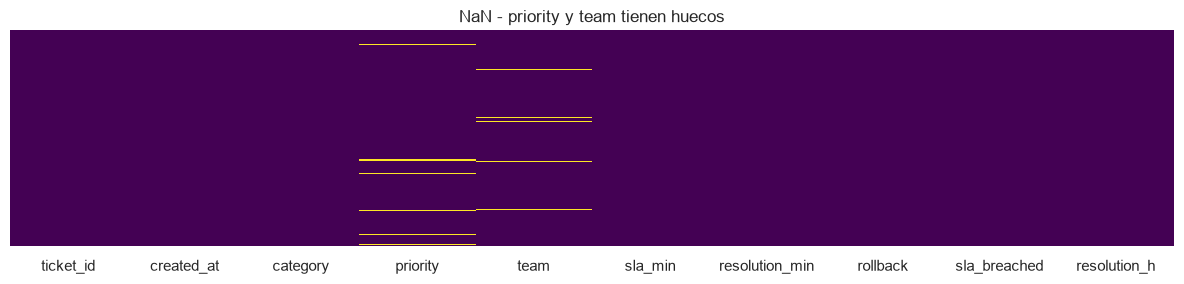

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

DATA = Path('..') / 'data'
tickets = pd.read_csv(DATA / 'tickets.csv', parse_dates=['created_at'])
# Columna humana: resolucion en horas
tickets['resolution_h'] = tickets['resolution_min'] / 60
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(tickets.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
ax.set_title('NaN - priority y team tienen huecos')
plt.tight_layout()
plt.savefig('../html/lab3_fig1_nan.png', dpi=110, bbox_inches='tight')
plt.show()

In [2]:
# Limpiar errores tecnicos: resolution <= 0 o > 100 000 (mas de 2 meses)
t = tickets[(tickets['resolution_min'] > 0) & (tickets['resolution_min'] < 100_000)].copy()
t['priority'] = t['priority'].fillna(t['priority'].mode().iloc[0])
t['team'] = t['team'].fillna(t['team'].mode().iloc[0])
print(f'limpiados: {len(tickets) - len(t)} filas con errores tecnicos')
print(f'Tickets validos: {len(t)}')
print('\nPor equipo:')
print(t['team'].value_counts())

limpiados: 40 filas con errores tecnicos
Tickets validos: 860

Por equipo:
team
identity    217
payments    174
platform    167
frontend    154
data        148
Name: count, dtype: int64


## 2. Heatmap de demanda por equipo x categoria

**Que decidimos:** el equipo con mas volumen total + la categoria dominante define donde reforzar personal.

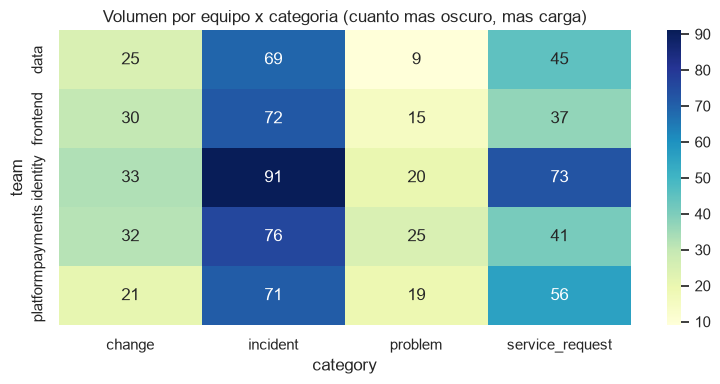

In [3]:
pivot = t.pivot_table(index='team', columns='category', values='ticket_id', aggfunc='count', fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', ax=ax)
ax.set_title('Volumen por equipo x categoria (cuanto mas oscuro, mas carga)')
plt.tight_layout()
plt.savefig('../html/lab3_fig2_heatmap.png', dpi=110, bbox_inches='tight')
plt.show()

## 3. Heatmap dia x hora x equipo - cuando hay tickets?

**Que vemos:** la densidad de tickets por equipo, por dia de la semana (eje Y) y hora del dia (eje X).

**Para que sirve:**
- **Picos claros en horas especificas** = oportunidad de rotacion de turnos
- **Distribucion uniforme** = no rotacion, sino contratar mas
- **Caida fuerte en finde** = oportunidad de automatizar tickets no urgentes

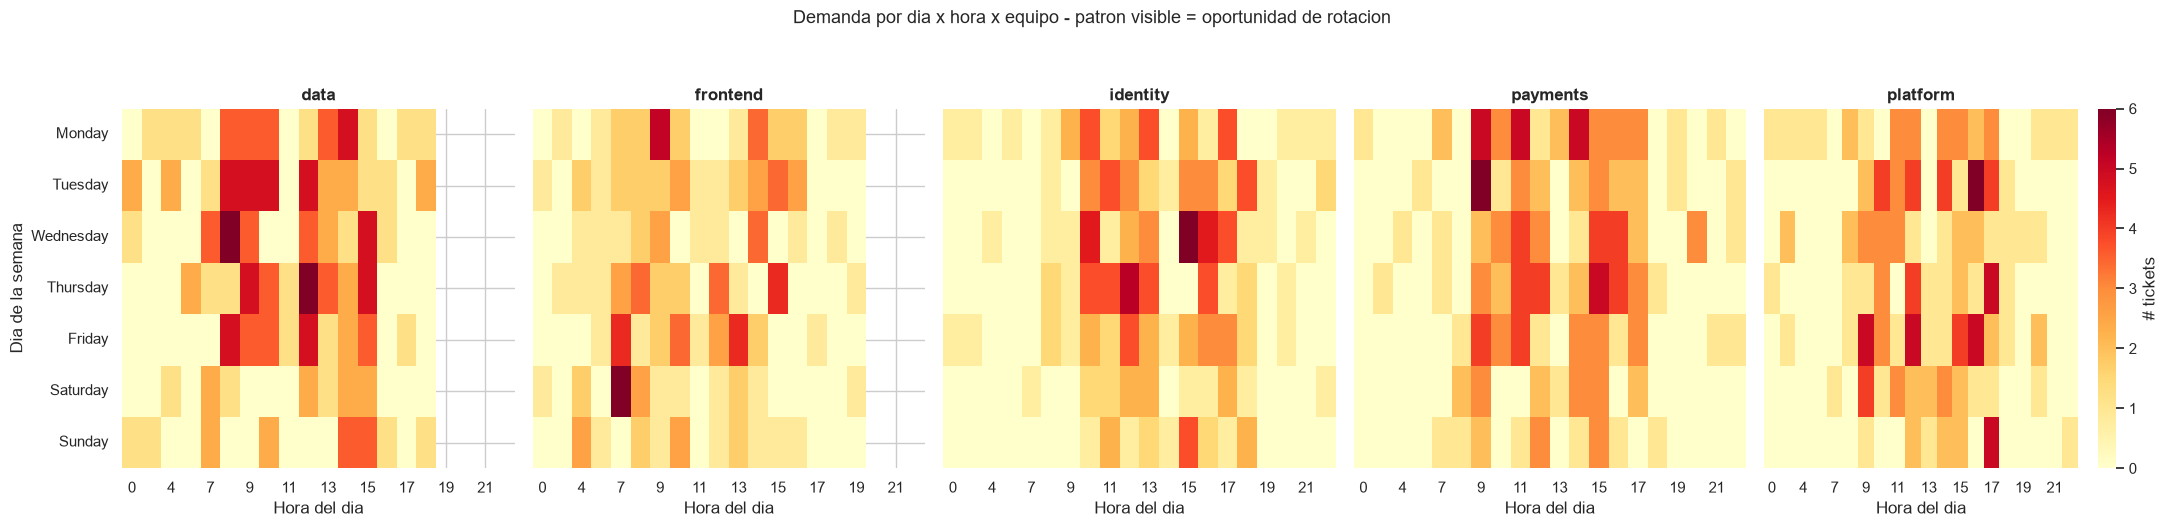

In [4]:
t['dow'] = t['created_at'].dt.day_name()
t['hour'] = t['created_at'].dt.hour
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
t['dow'] = pd.Categorical(t['dow'], categories=dow_order, ordered=True)

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True, sharex=True)
teams = sorted(t['team'].unique())
for ax, team in zip(axes, teams):
    sub = t[t['team'] == team]
    pivot = sub.pivot_table(index='dow', columns='hour', values='ticket_id', aggfunc='count', fill_value=0)
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd',
                cbar=(team == teams[-1]),
                cbar_kws={'label': '# tickets'} if team == teams[-1] else None)
    ax.set_title(team, fontsize=12, fontweight='bold')
    ax.set_xlabel('Hora del dia')
    ax.set_ylabel('Dia de la semana' if team == teams[0] else '')
fig.suptitle('Demanda por dia x hora x equipo - patron visible = oportunidad de rotacion', fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('../html/lab3_fig3_heatmap_demand.png', dpi=110, bbox_inches='tight')
plt.show()

## 4. Boxplot de tiempo de resolucion (horas)

**Que vemos:** la mediana dice cuanto tarda el caso tipico (horas). Los outliers arriba son incidentes graves.

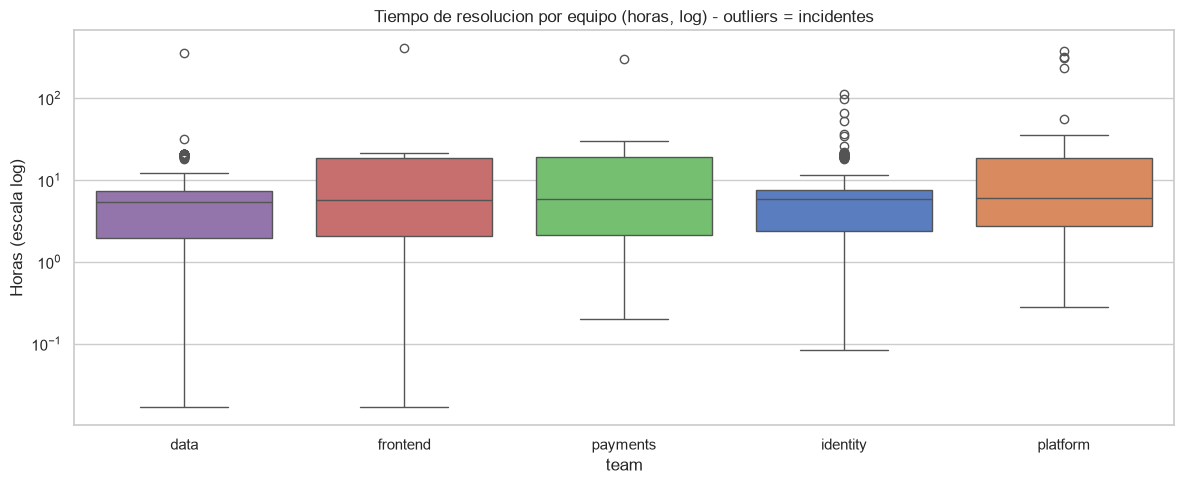

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
order = t.groupby('team')['resolution_h'].median().sort_values().index
sns.boxplot(data=t, x='team', y='resolution_h', order=order, hue='team', legend=False, ax=ax)
ax.set_yscale('log')
ax.set_title('Tiempo de resolucion por equipo (horas, log) - outliers = incidentes')
ax.set_ylabel('Horas (escala log)')
plt.tight_layout()
plt.savefig('../html/lab3_fig4_boxplot.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. Breach SLA - ¿donde perdemos dinero?

**Que decidimos:** cada breach SLA puede tener penalizacion contractual. El equipo con mayor breach rate es candidato a refuerzo.

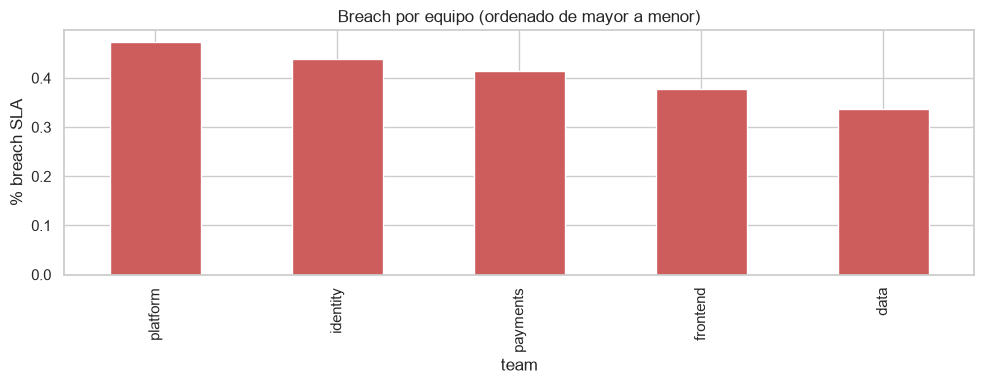

In [6]:
breach = t.groupby('team')['sla_breached'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
breach.plot(kind='bar', color='indianred', ax=ax)
ax.set_ylabel('% breach SLA')
ax.set_title('Breach por equipo (ordenado de mayor a menor)')
plt.tight_layout()
plt.savefig('../html/lab3_fig5_breach.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Tu decision como SRE

Mirando los datos:
- **Refuerzo de personal**: equipo con **mayor volumen total** en el heatmap team x categoria **y** alto % breach = candidato #1.
- **Rotacion de turnos**: equipo con **patron horario claro** en el heatmap dia x hora (ej: picos lunes 9-11am) = candidato a rotacion.
- **Dispersión de breach**: si breach esta en todos los equipos, el problema es global (proceso). Si esta en 1-2, el problema es local (equipo).

In [7]:
# Tabla resumen para tu decision
summary = t.groupby('team').agg(
    total_tickets=('ticket_id', 'count'),
    pct_breach=('sla_breached', lambda s: s.mean() * 100),
    avg_resolution_h=('resolution_h', 'mean'),
    pct_rollback=('rollback', lambda s: s.sum() / max((t['category']=='change').sum(), 1) * 100),
).round(2).sort_values('pct_breach', ascending=False)
summary

print('\nLectura:')
print('- Equipo con >30% breach: necesita refuerzo')
print('- Equipo con patron horario claro (heatmap sec 3): rotacion')
print('- Equipo con >20% rollback: proceso de cambios roto')


Lectura:
- Equipo con >30% breach: necesita refuerzo
- Equipo con patron horario claro (heatmap sec 3): rotacion
- Equipo con >20% rollback: proceso de cambios roto


## 7. Rollback en cambios por equipo

**Que decidimos:** un rollback rate alto = cambios mal probados o sin revision suficiente; candidato a postmortem del proceso de cambios.

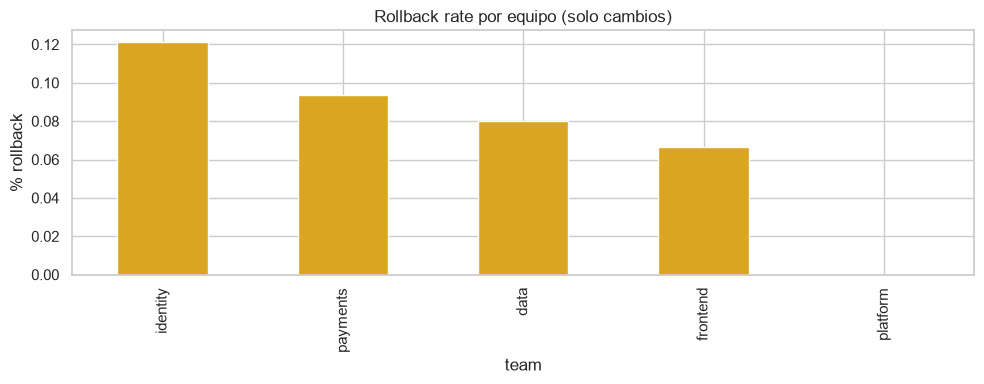

In [8]:
changes = t[t['category'] == 'change']
fig, ax = plt.subplots(figsize=(10, 4))
changes.groupby('team')['rollback'].mean().sort_values(ascending=False).plot(kind='bar', color='goldenrod', ax=ax)
ax.set_ylabel('% rollback')
ax.set_title('Rollback rate por equipo (solo cambios)')
plt.tight_layout()
plt.savefig('../html/lab3_fig6_rollback.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Para presentar al director

Tu headline (1 linea):

> «El equipo **[NOMBRE]** maneja el **X%** de los tickets con un **Y%** de breach SLA; rotamos turnos lunes-viernes 9-11am = **$Z** ahorrados en penalizaciones.»